# Earth2Studio: AI Weather Forecasting

This notebook demonstrates NVIDIA Earth2Studio for:
1. **2m Temperature** forecast (FCN)
2. **10m Wind Speed & MSLP** forecasts (SFNO)
3. **Hurricane Florence track comparison** (AIFS vs FCN vs ERA5 reanalysis)
4. **14-day extended range forecast** — Aurora Z500 animated GIF (Jan 2025 polar vortex)

### Prerequisites
- Python 3.12 with the `earth2` kernel
- `uv sync` (resolves all Earth2Studio extras)
- NVIDIA GPU with CUDA

---
## Imports & Config

In [2]:
import io
import os
from pathlib import Path
from datetime import datetime, timedelta

import imageio
import numpy as np
import torch
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from IPython.display import Image as IPImage
from tqdm import tqdm

os.environ["CUFILE_ENV_PATH_JSON"] = "/dev/null"

import earth2studio.run as run
from earth2studio.models.px import AIFS, Aurora, FCN, SFNO
from earth2studio.models.dx import TCTrackerWuDuan
from earth2studio.data import GFS, CDS, WB2ERA5, NCAR_ERA5, fetch_data, prep_data_array
from earth2studio.io import ZarrBackend
from earth2studio.utils.time import to_time_array
from earth2studio.utils.coords import map_coords

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
PROJECT_DIR = Path("/home/jovyan/Earth2")
os.chdir(PROJECT_DIR)

os.makedirs(PROJECT_DIR / "aifs_outputs", exist_ok=True)
os.makedirs(PROJECT_DIR / "aurora_outputs", exist_ok=True)

print(f"Device: {DEVICE}")

Device: cuda

In [1]:
import io
import os
from pathlib import Path
from datetime import datetime, timedelta

import imageio
import numpy as np
import torch
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from IPython.display import Image as IPImage
from tqdm import tqdm

os.environ["CUFILE_ENV_PATH_JSON"] = "/dev/null"

import earth2studio.run as run
from earth2studio.models.px import AIFS, Aurora, FCN, SFNO
from earth2studio.models.dx import TCTrackerWuDuan
from earth2studio.data import GFS, CDS, WB2ERA5, NCAR_ERA5, fetch_data, prep_data_array
from earth2studio.io import ZarrBackend
from earth2studio.utils.time import to_time_array
from earth2studio.utils.coords import map_coords

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
PROJECT_DIR = Path("/home/jovyan/Earth2")
os.chdir(PROJECT_DIR)

os.makedirs(PROJECT_DIR / "aifs_outputs", exist_ok=True)
os.makedirs(PROJECT_DIR / "aurora_outputs", exist_ok=True)

print(f"Device: {DEVICE}")

/home/jovyan/Earth2/.venv/lib/python3.12/site-packages/torch/cuda/__init__.py:61: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]/home/jovyan/Earth2/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm/home/jovyan/Earth2/.venv/lib/python3.12/site-packages/torch/cuda/__init__.py:61: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]

Warp DeprecationWarning: The symbol `warp.context.Device` will soon be removed from the public API. Use `warp.Device` instead. parsing error, invalid json config /dev/null
 failed to load user config: /dev/null Invalid argument
 cuFile configuration load error
 cuFile initialization failedCuPy distance computation test failed with error: cuVS >= 24.12 or pylibraft < 24.12 should be installed to use this featureDevice: cuda

## 2m Air Temperature Forecast

In [3]:
model = FCN.load_model(FCN.load_default_package())
data = GFS()

t2m_path = PROJECT_DIR/"t2m_outputs/fcn_gfs_forecast.zarr"
backend = ZarrBackend(str(t2m_path), backend_kwargs={"overwrite": True})

backend = run.deterministic(["2026-01-08"], 10, model, data, backend)
print(backend.root.tree())

del model
torch.cuda.empty_cache()

2026-06-01 21:02:31.879 | INFO     | earth2studio.run:deterministic:78 - Running simple workflow!
2026-06-01 21:02:31.881 | INFO     | earth2studio.run:deterministic:85 - Inference device: cuda

Fetching GFS data:   0%|          | 0/26 [00:00<?, ?it/s]

2026-06-01 21:02:33.905 | DEBUG    | earth2studio.data.gfs:fetch_array:367 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20260108/00/atmos/gfs.t00z.pgrb2.0p25.f000 414147575-944928

Fetching GFS data:   0%|          | 0/26 [00:01<?, ?it/s]

2026-06-01 21:02:35.512 | DEBUG    | earth2studio.data.gfs:fetch_array:367 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20260108/00/atmos/gfs.t00z.pgrb2.0p25.f000 330543720-841319
2026-06-01 21:02:35.557 | DEBUG    | earth2studio.data.gfs:fetch_array:367 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20260108/00/atmos/gfs.t00z.pgrb2.0p25.f000 252299022-805146
2026-06-01 21:02:35.602 | DEBUG    | earth2studio.data.gfs:fetch_array:367 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20260108/00/atmos/gfs.t00z.pgrb2.0p25.f000 199554862-723222
2026-06-01 21:02:35.644 | DEBUG    | earth2studio.data.gfs:fetch_array:367 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20260108/00/atmos/gfs.t00z.pgrb2.0p25.f000 253104168-716388
2026-06-01 21:02:35.669 | DEBUG    | earth2studio.data.gfs:fetch_array:367 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20260108/00/atmos/gfs.t00z.pgrb2.0p25.f000 200278084-732664

...

2026-06-01 21:02:36.488 | DEBUG    | earth2studio.data.gfs:fetch_array:367 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20260108/00/atmos/gfs.t00z.pgrb2.0p25.f000 459253427-968705
2026-06-01 21:02:36.556 | DEBUG    | earth2studio.data.gfs:fetch_array:367 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20260108/00/atmos/gfs.t00z.pgrb2.0p25.f000 258609745-911055
2026-06-01 21:02:36.602 | DEBUG    | earth2studio.data.gfs:fetch_array:367 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20260108/00/atmos/gfs.t00z.pgrb2.0p25.f000 205446434-581059

Fetching GFS data: 100%|██████████| 26/26 [00:02<00:00,  8.99it/s]

2026-06-01 21:02:36.699 | DEBUG    | earth2studio.data.gfs:fetch_array:367 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20260108/00/atmos/gfs.t00z.pgrb2.0p25.f000 0-876451
2026-06-01 21:02:36.736 | DEBUG    | earth2studio.data.gfs:fetch_array:367 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20260108/00/atmos/gfs.t00z.pgrb2.0p25.f000 259520800-914487
2026-06-01 21:02:36.774 | DEBUG    | earth2studio.data.gfs:fetch_array:367 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20260108/00/atmos/gfs.t00z.pgrb2.0p25.f000 206027493-586285
2026-06-01 21:02:36.887 | SUCCESS  | earth2studio.run:deterministic:109 - Fetched data from GFS2026-06-01 21:02:37.142 | INFO     | earth2studio.run:deterministic:139 - Inference starting!

Running inference: 100%|██████████| 11/11 [00:15<00:00,  1.38s/it]

2026-06-01 21:02:52.313 | SUCCESS  | earth2studio.run:deterministic:151 - 
Inference complete
/
├── lat (720,) float64
├── lead_time (11,) timedelta64[h]
├── lon (1440,) float64
├── msl (1, 11, 720, 1440) float32
├── r500 (1, 11, 720, 1440) float32
├── r850 (1, 11, 720, 1440) float32
├── sp (1, 11, 720, 1440) float32
├── t250 (1, 11, 720, 1440) float32
├── t2m (1, 11, 720, 1440) float32
├── t500 (1, 11, 720, 1440) float32
├── t850 (1, 11, 720, 1440) float32
├── tcwv (1, 11, 720, 1440) float32
├── time (1,) datetime64[ns]
├── u1000 (1, 11, 720, 1440) float32
├── u100m (1, 11, 720, 1440) float32
├── u10m (1, 11, 720, 1440) float32
├── u250 (1, 11, 720, 1440) float32
├── u500 (1, 11, 720, 1440) float32
├── u850 (1, 11, 720, 1440) float32
├── v1000 (1, 11, 720, 1440) float32
├── v100m (1, 11, 720, 1440) float32
├── v10m (1, 11, 720, 1440) float32
├── v250 (1, 11, 720, 1440) float32
├── v500 (1, 11, 720, 1440) float32
├── v850 (1, 11, 720, 1440) float32
├── z1000 (1, 11, 720, 1440) float32


In [4]:
model = FCN.load_model(FCN.load_default_package())
data = GFS()

t2m_path = PROJECT_DIR/"t2m_outputs/fcn_gfs_forecast.zarr"
backend = ZarrBackend(str(t2m_path), backend_kwargs={"overwrite": True})

backend = run.deterministic(["2026-01-08"], 10, model, data, backend)
print(backend.root.tree())

del model
torch.cuda.empty_cache()

2026-06-01 21:02:53.537 | INFO     | earth2studio.run:deterministic:78 - Running simple workflow!
2026-06-01 21:02:53.537 | INFO     | earth2studio.run:deterministic:85 - Inference device: cuda

Fetching GFS data:   0%|          | 0/26 [00:00<?, ?it/s]

2026-06-01 21:02:54.077 | DEBUG    | earth2studio.data.gfs:fetch_array:367 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20260108/00/atmos/gfs.t00z.pgrb2.0p25.f000 394176955-956678
2026-06-01 21:02:54.097 | DEBUG    | earth2studio.data.gfs:fetch_array:367 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20260108/00/atmos/gfs.t00z.pgrb2.0p25.f000 259520800-914487
2026-06-01 21:02:54.115 | DEBUG    | earth2studio.data.gfs:fetch_array:367 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20260108/00/atmos/gfs.t00z.pgrb2.0p25.f000 393209495-967460
2026-06-01 21:02:54.132 | DEBUG    | earth2studio.data.gfs:fetch_array:367 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20260108/00/atmos/gfs.t00z.pgrb2.0p25.f000 258609745-911055
2026-06-01 21:02:54.149 | DEBUG    | earth2studio.data.gfs:fetch_array:367 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20260108/00/atmos/gfs.t00z.pgrb2.0p25.f000 200278084-732664
2026-06-01 21:02:54.167 | DEBUG    | earth2studio.data.gfs:fetch_array:367 - Fetching GFS 

Fetching GFS data:   0%|          | 0/26 [00:00<?, ?it/s]

2026-06-01 21:02:54.290 | DEBUG    | earth2studio.data.gfs:fetch_array:367 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20260108/00/atmos/gfs.t00z.pgrb2.0p25.f000 336364985-938149
2026-06-01 21:02:54.306 | DEBUG    | earth2studio.data.gfs:fetch_array:367 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20260108/00/atmos/gfs.t00z.pgrb2.0p25.f000 414147575-944928
2026-06-01 21:02:54.323 | DEBUG    | earth2studio.data.gfs:fetch_array:367 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20260108/00/atmos/gfs.t00z.pgrb2.0p25.f000 331385039-869528
2026-06-01 21:02:54.339 | DEBUG    | earth2studio.data.gfs:fetch_array:367 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20260108/00/atmos/gfs.t00z.pgrb2.0p25.f000 205446434-581059
2026-06-01 21:02:54.356 | DEBUG    | earth2studio.data.gfs:fetch_array:367 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20260108/00/atmos/gfs.t00z.pgrb2.0p25.f000 400526668-837990
2026-06-01 21:02:54.372 | DEBUG    | earth2studio.data.gfs:fetch_array:367 - Fetching GFS 

Fetching GFS data: 100%|██████████| 26/26 [00:00<00:00, 56.54it/s]

2026-06-01 21:02:54.503 | DEBUG    | earth2studio.data.gfs:fetch_array:367 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20260108/00/atmos/gfs.t00z.pgrb2.0p25.f000 252299022-805146
2026-06-01 21:02:54.520 | DEBUG    | earth2studio.data.gfs:fetch_array:367 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20260108/00/atmos/gfs.t00z.pgrb2.0p25.f000 199554862-723222
2026-06-01 21:02:54.612 | SUCCESS  | earth2studio.run:deterministic:109 - Fetched data from GFS2026-06-01 21:02:54.899 | INFO     | earth2studio.run:deterministic:139 - Inference starting!

Running inference: 100%|██████████| 11/11 [00:10<00:00,  1.03it/s]

2026-06-01 21:03:05.555 | SUCCESS  | earth2studio.run:deterministic:151 - 
Inference complete
/
├── lat (720,) float64
├── lead_time (11,) timedelta64[h]
├── lon (1440,) float64
├── msl (1, 11, 720, 1440) float32
├── r500 (1, 11, 720, 1440) float32
├── r850 (1, 11, 720, 1440) float32
├── sp (1, 11, 720, 1440) float32
├── t250 (1, 11, 720, 1440) float32
├── t2m (1, 11, 720, 1440) float32
├── t500 (1, 11, 720, 1440) float32
├── t850 (1, 11, 720, 1440) float32
├── tcwv (1, 11, 720, 1440) float32
├── time (1,) datetime64[ns]
├── u1000 (1, 11, 720, 1440) float32
├── u100m (1, 11, 720, 1440) float32
├── u10m (1, 11, 720, 1440) float32
├── u250 (1, 11, 720, 1440) float32
├── u500 (1, 11, 720, 1440) float32
├── u850 (1, 11, 720, 1440) float32
├── v1000 (1, 11, 720, 1440) float32
├── v100m (1, 11, 720, 1440) float32
├── v10m (1, 11, 720, 1440) float32
├── v250 (1, 11, 720, 1440) float32
├── v500 (1, 11, 720, 1440) float32
├── v850 (1, 11, 720, 1440) float32
├── z1000 (1, 11, 720, 1440) float32


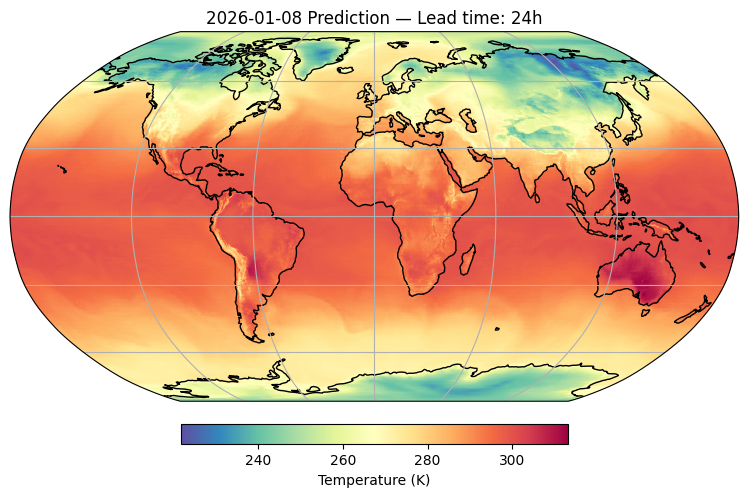

In [13]:
def plot_t2m(zarr_path, variable, step, save_path=None):
    ds = xr.open_zarr(str(zarr_path))
    projection = ccrs.Robinson()

    fig, ax = plt.subplots(subplot_kw={"projection": projection}, figsize=(10, 6))
    im = ax.pcolormesh(
        ds["lon"], ds["lat"], ds[variable][0, step],
        transform=ccrs.PlateCarree(), cmap="Spectral_r",
    )
    plt.colorbar(
            im, 
            ax=ax, 
            orientation="horizontal", 
            pad=0.05, 
            label="Temperature (K)",
            shrink=0.5,  
            aspect=20
)

    ax.set_title(f"2026-01-08 Prediction — Lead time: {6 * step}h")
    ax.coastlines()
    ax.gridlines()

    if save_path:
        plt.savefig(save_path, bbox_inches="tight")
    plt.show()

plot_t2m(t2m_path, "t2m", step=4, save_path=PROJECT_DIR / "t2m_outputs/t2m_prediction.jpg")

---
## 10m Wind Speed & MSLP Forecasts (SFNO)

In [10]:
sfno_model = SFNO.load_model(SFNO.load_default_package())
data = GFS()

sfno_path = PROJECT_DIR / "sfno_outputs/sfno_gfs_forecast.zarr"
sfno_path.parent.mkdir(parents=True, exist_ok=True)
backend = ZarrBackend(str(sfno_path), backend_kwargs={"overwrite": True})

backend = run.deterministic(["2026-01-01"], 10, sfno_model, data, backend)
print(backend.root.tree())

del sfno_model
torch.cuda.empty_cache()

2026-06-01 21:05:35.391 | INFO     | earth2studio.run:deterministic:78 - Running simple workflow!
2026-06-01 21:05:35.391 | INFO     | earth2studio.run:deterministic:85 - Inference device: cuda

Fetching GFS data:   0%|          | 0/73 [00:00<?, ?it/s]

2026-06-01 21:05:35.827 | DEBUG    | earth2studio.data.gfs:fetch_array:367 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20260101/00/atmos/gfs.t00z.pgrb2.0p25.f000 342871367-937042
2026-06-01 21:05:35.845 | DEBUG    | earth2studio.data.gfs:fetch_array:367 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20260101/00/atmos/gfs.t00z.pgrb2.0p25.f000 186539908-1157722
2026-06-01 21:05:35.862 | DEBUG    | earth2studio.data.gfs:fetch_array:367 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20260101/00/atmos/gfs.t00z.pgrb2.0p25.f000 309676164-899071
2026-06-01 21:05:35.878 | DEBUG    | earth2studio.data.gfs:fetch_array:367 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20260101/00/atmos/gfs.t00z.pgrb2.0p25.f000 397402082-1223716
2026-06-01 21:05:35.894 | DEBUG    | earth2studio.data.gfs:fetch_array:367 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20260101/00/atmos/gfs.t00z.pgrb2.0p25.f000 215568560-734824
2026-06-01 21:05:35.911 | DEBUG    | earth2studio.data.gfs:fetch_array:367 - Fetching GF

Fetching GFS data:   0%|          | 0/73 [00:00<?, ?it/s]

2026-06-01 21:05:36.039 | DEBUG    | earth2studio.data.gfs:fetch_array:367 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20260101/00/atmos/gfs.t00z.pgrb2.0p25.f000 303223032-755488
2026-06-01 21:05:36.055 | DEBUG    | earth2studio.data.gfs:fetch_array:367 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20260101/00/atmos/gfs.t00z.pgrb2.0p25.f000 210945366-591794
2026-06-01 21:05:36.071 | DEBUG    | earth2studio.data.gfs:fetch_array:367 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20260101/00/atmos/gfs.t00z.pgrb2.0p25.f000 400502176-971362
2026-06-01 21:05:36.087 | DEBUG    | earth2studio.data.gfs:fetch_array:367 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20260101/00/atmos/gfs.t00z.pgrb2.0p25.f000 207509484-1165049
2026-06-01 21:05:36.107 | DEBUG    | earth2studio.data.gfs:fetch_array:367 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20260101/00/atmos/gfs.t00z.pgrb2.0p25.f000 367926743-957726
2026-06-01 21:05:36.124 | DEBUG    | earth2studio.data.gfs:fetch_array:367 - Fetching GFS

...

2026-06-01 21:05:36.670 | DEBUG    | earth2studio.data.gfs:fetch_array:367 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20260101/00/atmos/gfs.t00z.pgrb2.0p25.f000 189836330-978278
2026-06-01 21:05:36.686 | DEBUG    | earth2studio.data.gfs:fetch_array:367 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20260101/00/atmos/gfs.t00z.pgrb2.0p25.f000 395488198-871807
2026-06-01 21:05:36.703 | DEBUG    | earth2studio.data.gfs:fetch_array:367 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20260101/00/atmos/gfs.t00z.pgrb2.0p25.f000 222511451-619141
2026-06-01 21:05:36.720 | DEBUG    | earth2studio.data.gfs:fetch_array:367 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20260101/00/atmos/gfs.t00z.pgrb2.0p25.f000 305163964-1255574
2026-06-01 21:05:36.736 | DEBUG    | earth2studio.data.gfs:fetch_array:367 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20260101/00/atmos/gfs.t00z.pgrb2.0p25.f000 184289895-747900
2026-06-01 21:05:36.753 | DEBUG    | earth2studio.data.gfs:fetch_array:367 - Fetching GFS

Fetching GFS data: 100%|██████████| 73/73 [00:01<00:00, 60.92it/s]

2026-06-01 21:05:36.883 | DEBUG    | earth2studio.data.gfs:fetch_array:367 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20260101/00/atmos/gfs.t00z.pgrb2.0p25.f000 258526459-815588
2026-06-01 21:05:36.900 | DEBUG    | earth2studio.data.gfs:fetch_array:367 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20260101/00/atmos/gfs.t00z.pgrb2.0p25.f000 466463325-975726
2026-06-01 21:05:36.915 | DEBUG    | earth2studio.data.gfs:fetch_array:367 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20260101/00/atmos/gfs.t00z.pgrb2.0p25.f000 238402444-729443
2026-06-01 21:05:36.930 | DEBUG    | earth2studio.data.gfs:fetch_array:367 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20260101/00/atmos/gfs.t00z.pgrb2.0p25.f000 180067903-910623
2026-06-01 21:05:36.945 | DEBUG    | earth2studio.data.gfs:fetch_array:367 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20260101/00/atmos/gfs.t00z.pgrb2.0p25.f000 175600465-1122214
2026-06-01 21:05:36.961 | DEBUG    | earth2studio.data.gfs:fetch_array:367 - Fetching GFS

Running inference: 100%|██████████| 11/11 [00:30<00:00,  2.75s/it]

2026-06-01 21:06:07.629 | SUCCESS  | earth2studio.run:deterministic:151 - 
Inference complete
/
├── lat (721,) float64
├── lead_time (11,) timedelta64[h]
├── lon (1440,) float64
├── msl (1, 11, 721, 1440) float32
├── q100 (1, 11, 721, 1440) float32
├── q1000 (1, 11, 721, 1440) float32
├── q150 (1, 11, 721, 1440) float32
├── q200 (1, 11, 721, 1440) float32
├── q250 (1, 11, 721, 1440) float32
├── q300 (1, 11, 721, 1440) float32
├── q400 (1, 11, 721, 1440) float32
├── q50 (1, 11, 721, 1440) float32
├── q500 (1, 11, 721, 1440) float32
├── q600 (1, 11, 721, 1440) float32
├── q700 (1, 11, 721, 1440) float32
├── q850 (1, 11, 721, 1440) float32
├── q925 (1, 11, 721, 1440) float32
├── sp (1, 11, 721, 1440) float32
├── t100 (1, 11, 721, 1440) float32
├── t1000 (1, 11, 721, 1440) float32
├── t150 (1, 11, 721, 1440) float32
├── t200 (1, 11, 721, 1440) float32
├── t250 (1, 11, 721, 1440) float32
├── t2m (1, 11, 721, 1440) float32
├── t300 (1, 11, 721, 1440) float32
├── t400 (1, 11, 721, 1440) float

In [5]:
sfno_model = SFNO.load_model(SFNO.load_default_package())
data = GFS()

sfno_path = PROJECT_DIR / "sfno_outputs/sfno_gfs_forecast.zarr"
sfno_path.parent.mkdir(parents=True, exist_ok=True)
backend = ZarrBackend(str(sfno_path), backend_kwargs={"overwrite": True})

backend = run.deterministic(["2026-01-01"], 10, sfno_model, data, backend)
print(backend.root.tree())

del sfno_model
torch.cuda.empty_cache()

2026-06-01 21:04:08.468 | INFO     | earth2studio.run:deterministic:78 - Running simple workflow!
2026-06-01 21:04:08.469 | INFO     | earth2studio.run:deterministic:85 - Inference device: cuda

Fetching GFS data:   0%|          | 0/73 [00:00<?, ?it/s]

2026-06-01 21:04:08.942 | DEBUG    | earth2studio.data.gfs:fetch_array:367 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20260101/00/atmos/gfs.t00z.pgrb2.0p25.f000 179147390-920513
2026-06-01 21:04:09.002 | DEBUG    | earth2studio.data.gfs:fetch_array:367 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20260101/00/atmos/gfs.t00z.pgrb2.0p25.f000 366981432-945311
2026-06-01 21:04:09.046 | DEBUG    | earth2studio.data.gfs:fetch_array:367 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20260101/00/atmos/gfs.t00z.pgrb2.0p25.f000 204810809-740825
2026-06-01 21:04:09.088 | DEBUG    | earth2studio.data.gfs:fetch_array:367 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20260101/00/atmos/gfs.t00z.pgrb2.0p25.f000 287974570-901514

Fetching GFS data:   0%|          | 0/73 [00:00<?, ?it/s]

2026-06-01 21:04:09.170 | DEBUG    | earth2studio.data.gfs:fetch_array:367 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20260101/00/atmos/gfs.t00z.pgrb2.0p25.f000 174175517-762708
2026-06-01 21:04:09.211 | DEBUG    | earth2studio.data.gfs:fetch_array:367 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20260101/00/atmos/gfs.t00z.pgrb2.0p25.f000 361131975-856944

...

2026-06-01 21:04:14.369 | DEBUG    | earth2studio.data.gfs:fetch_array:367 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20260101/00/atmos/gfs.t00z.pgrb2.0p25.f000 152727639-744332
2026-06-01 21:04:14.493 | DEBUG    | earth2studio.data.gfs:fetch_array:367 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20260101/00/atmos/gfs.t00z.pgrb2.0p25.f000 337047752-847146
2026-06-01 21:04:14.530 | DEBUG    | earth2studio.data.gfs:fetch_array:367 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20260101/00/atmos/gfs.t00z.pgrb2.0p25.f000 261315236-1275503

Fetching GFS data: 100%|██████████| 73/73 [00:05<00:00, 12.94it/s]

2026-06-01 21:04:14.834 | SUCCESS  | earth2studio.run:deterministic:109 - Fetched data from GFS
2026-06-01 21:04:14.952 | INFO     | earth2studio.run:deterministic:139 - Inference starting!

Running inference: 100%|██████████| 11/11 [00:51<00:00,  4.72s/it]

2026-06-01 21:05:06.875 | SUCCESS  | earth2studio.run:deterministic:151 - 
Inference complete
/
├── lat (721,) float64
├── lead_time (11,) timedelta64[h]
├── lon (1440,) float64
├── msl (1, 11, 721, 1440) float32
├── q100 (1, 11, 721, 1440) float32
├── q1000 (1, 11, 721, 1440) float32
├── q150 (1, 11, 721, 1440) float32
├── q200 (1, 11, 721, 1440) float32
├── q250 (1, 11, 721, 1440) float32
├── q300 (1, 11, 721, 1440) float32
├── q400 (1, 11, 721, 1440) float32
├── q50 (1, 11, 721, 1440) float32
├── q500 (1, 11, 721, 1440) float32
├── q600 (1, 11, 721, 1440) float32
├── q700 (1, 11, 721, 1440) float32
├── q850 (1, 11, 721, 1440) float32
├── q925 (1, 11, 721, 1440) float32
├── sp (1, 11, 721, 1440) float32
├── t100 (1, 11, 721, 1440) float32
├── t1000 (1, 11, 721, 1440) float32
├── t150 (1, 11, 721, 1440) float32
├── t200 (1, 11, 721, 1440) float32
├── t250 (1, 11, 721, 1440) float32
├── t2m (1, 11, 721, 1440) float32
├── t300 (1, 11, 721, 1440) float32
├── t400 (1, 11, 721, 1440) float

In [24]:
def plot_sfno_10m_wind(zarr_path, step, extent=None, save_path=None):
    ds = xr.open_zarr(str(zarr_path))
    ws10 = np.sqrt(ds["u10m"][0, step] ** 2 + ds["v10m"][0, step] ** 2)
    projection = ccrs.Robinson()
    levels = np.arange(0, 40, 2)

    fig, ax = plt.subplots(subplot_kw={"projection": projection}, figsize=(12, 6))
    im = ax.contourf(
        ds["lon"], ds["lat"], ws10, levels,
        transform=ccrs.PlateCarree(), cmap="YlOrRd", extend="neither",
    )
    plt.colorbar(im, ax=ax, shrink=0.5, pad=0.04, label="10 m Wind Speed (m/s)", orientation="horizontal")
    ax.set_title(f"SFNO — 2026-01-01 — 10 m Wind Speed — Lead time: {6 * step}h")
    if extent:
        ax.set_extent(extent, crs=ccrs.PlateCarree())
    ax.coastlines()
    ax.gridlines()
    if save_path:
        plt.savefig(str(save_path), bbox_inches="tight")
    plt.show()


def plot_sfno_msl(zarr_path, step, extent=None, save_path=None):
    ds = xr.open_zarr(str(zarr_path))
    msl_hpa = ds["msl"][0, step] / 100.0
    projection = ccrs.Robinson()
    levels = np.arange(960, 1045, 4)

    fig, ax = plt.subplots(subplot_kw={"projection": projection}, figsize=(12, 6))
    im = ax.contourf(
        ds["lon"], ds["lat"], msl_hpa, levels,
        transform=ccrs.PlateCarree(), cmap="jet", extend="neither",
    )
    plt.colorbar(im, ax=ax, shrink=0.5, pad=0.04, label="Mean Sea Level Pressure (hPa)", orientation="horizontal")
    ax.set_title(f"SFNO — 2026-01-01 — MSLP — Lead time: {6 * step}h")
    if extent:
        ax.set_extent(extent, crs=ccrs.PlateCarree())
    ax.coastlines()
    ax.gridlines()
    if save_path:
        plt.savefig(str(save_path), bbox_inches="tight")
    plt.show()

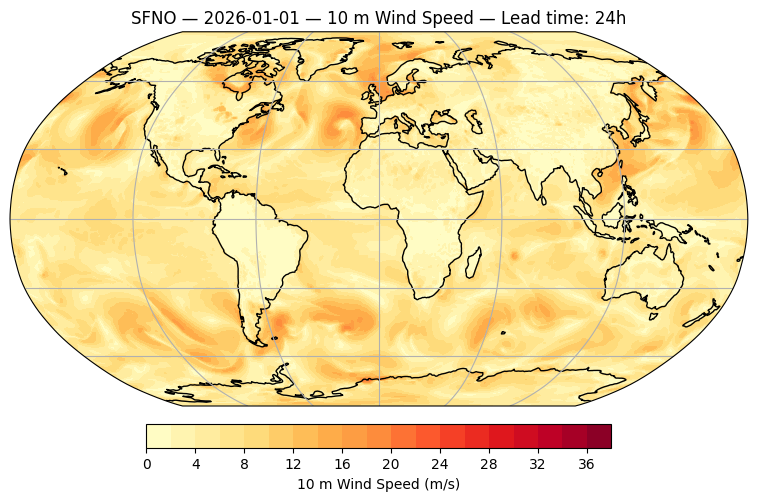

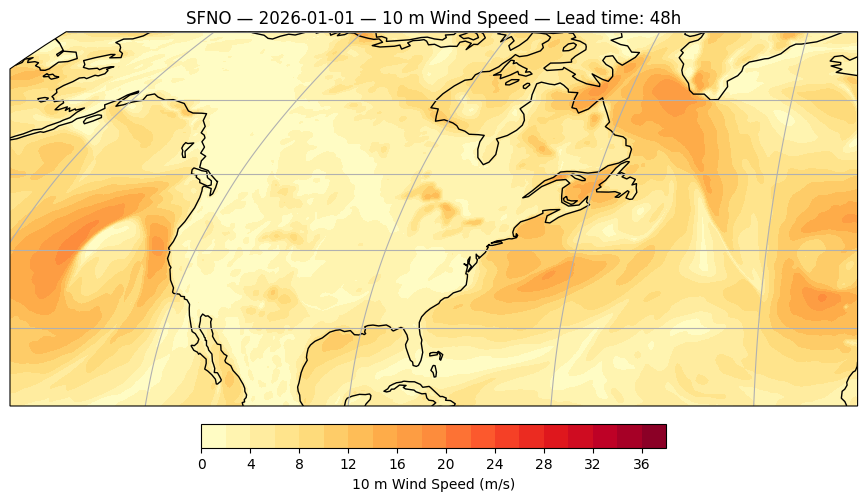

In [25]:
# 10m wind speed
plot_sfno_10m_wind(sfno_path, step=4)
plot_sfno_10m_wind(sfno_path, step=8, extent=[220, 340, 20, 70])

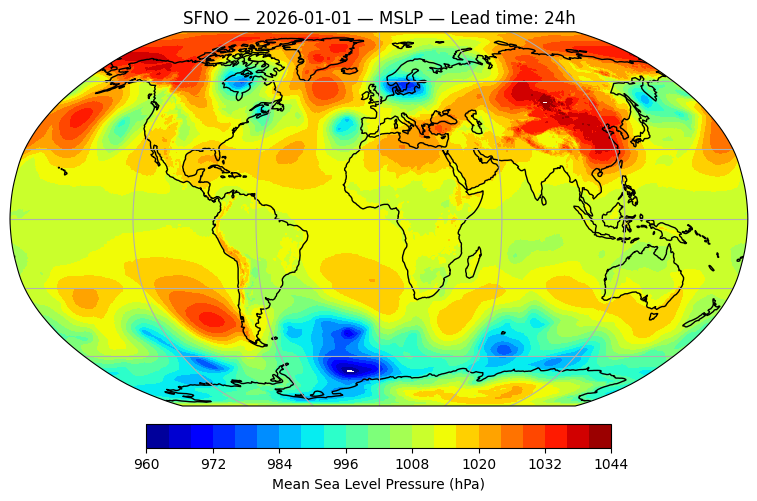

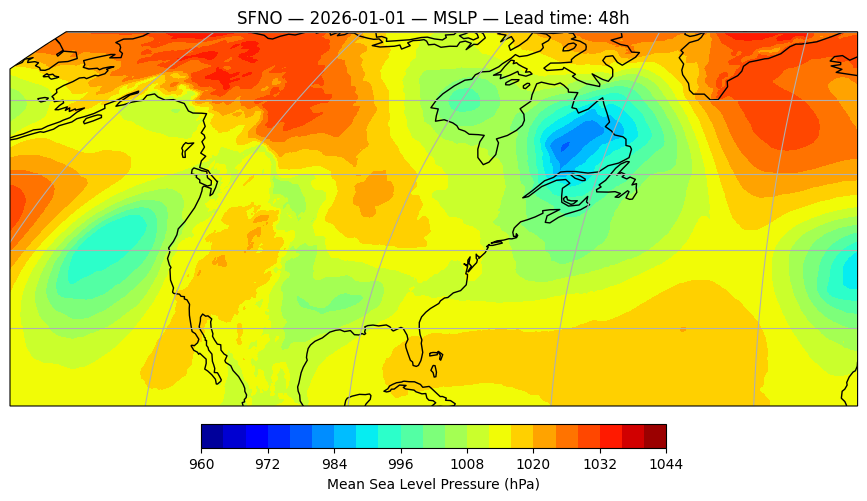

In [8]:
# Mean sea level pressure
plot_sfno_msl(sfno_path, step=4)
plot_sfno_msl(sfno_path, step=8, extent=[220, 340, 20, 70])

## Hurricane Florence Track Comparison

Compare tropical cyclone tracks from AIFS (ECMWF), FCN (NVIDIA), and ERA5 reanalysis
for Hurricane Florence (September 2018).

In [9]:
FLORENCE_DIR = PROJECT_DIR / "florence_outputs"
FLORENCE_DIR.mkdir(exist_ok=True)

START_TIME = datetime(2018, 9, 13)
NSTEPS = 25
END_TIME = START_TIME + timedelta(hours=6 * NSTEPS)

### Inference helper

In [11]:
def run_tc_inference(prognostic, data_source, tracker, start_time, nsteps, save_path):
    """Run a prognostic model through the TC tracker and save the resulting tracks."""
    prognostic = prognostic.to(DEVICE)
    tracker.reset_path_buffer()

    x, coords = fetch_data(
        source=data_source,
        time=to_time_array([start_time]),
        variable=prognostic.input_coords()["variable"],
        lead_time=prognostic.input_coords()["lead_time"],
        device=DEVICE,
    )
    x, coords = map_coords(x, coords, prognostic.input_coords())

    iterator = prognostic.create_iterator(x, coords)
    for step, (x, coords) in tqdm(enumerate(iterator), total=nsteps + 1):
        x, coords = map_coords(x, coords, tracker.input_coords())
        output, _ = tracker(x, coords)
        output = output[:, 0]
        if step == nsteps:
            break

    tracks = output.cpu()
    torch.save(tracks, str(save_path))
    print(f"Saved: {save_path}")
    return tracks

### 3a — AIFS (ECMWF)

In [12]:
aifs_model = AIFS.load_model(AIFS.load_default_package())
cds_data = CDS(cache=True)
tracker = TCTrackerWuDuan()

aifs_tracks = run_tc_inference(
    aifs_model, cds_data, tracker,
    START_TIME, NSTEPS, FLORENCE_DIR / "aifs_paths.pt",
)

del aifs_model
torch.cuda.empty_cache()

2026-06-01 21:06:42.789 | INFO     | earth2studio.data.cds:_fetch_process:177 - Fetching CDS grib file for variable: 10m_u_component_of_wind at 2018-09-12 18:00:00 with 1 levels
2026-06-01 21:06:42.840 | INFO     | earth2studio.data.cds:_fetch_process:177 - Fetching CDS grib file for variable: 10m_v_component_of_wind at 2018-09-12 18:00:00 with 1 levels
2026-06-01 21:06:42.840 | INFO     | earth2studio.data.cds:_fetch_process:177 - Fetching CDS grib file for variable: 2m_dewpoint_temperature at 2018-09-12 18:00:00 with 1 levels
2026-06-01 21:06:42.840 | INFO     | earth2studio.data.cds:_fetch_process:177 - Fetching CDS grib file for variable: 2m_temperature at 2018-09-12 18:00:00 with 1 levels
2026-06-01 21:06:42.840 | INFO     | earth2studio.data.cds:_fetch_process:177 - Fetching CDS grib file for variable: mean_sea_level_pressure at 2018-09-12 18:00:00 with 1 levels
2026-06-01 21:06:42.840 | INFO     | earth2studio.data.cds:_fetch_process:177 - Fetching CDS grib file for variable: sp

 96%|█████████▌| 25/26 [00:27<00:01,  1.12s/it]

Saved: /home/jovyan/Earth2/florence_outputs/aifs_paths.pt

In [14]:
aifs_model = AIFS.load_model(AIFS.load_default_package())
cds_data = CDS(cache=True)
tracker = TCTrackerWuDuan()

aifs_tracks = run_tc_inference(
    aifs_model, cds_data, tracker,
    START_TIME, NSTEPS, FLORENCE_DIR / "aifs_paths.pt",
)

del aifs_model
torch.cuda.empty_cache()

2026-06-01 21:07:44.565 | INFO     | earth2studio.data.cds:_fetch_process:177 - Fetching CDS grib file for variable: 10m_u_component_of_wind at 2018-09-12 18:00:00 with 1 levels
2026-06-01 21:07:44.565 | INFO     | earth2studio.data.cds:_fetch_process:177 - Fetching CDS grib file for variable: 10m_v_component_of_wind at 2018-09-12 18:00:00 with 1 levels
2026-06-01 21:07:44.565 | INFO     | earth2studio.data.cds:_fetch_process:177 - Fetching CDS grib file for variable: 2m_dewpoint_temperature at 2018-09-12 18:00:00 with 1 levels
2026-06-01 21:07:44.565 | INFO     | earth2studio.data.cds:_fetch_process:177 - Fetching CDS grib file for variable: 2m_temperature at 2018-09-12 18:00:00 with 1 levels
2026-06-01 21:07:44.565 | INFO     | earth2studio.data.cds:_fetch_process:177 - Fetching CDS grib file for variable: mean_sea_level_pressure at 2018-09-12 18:00:00 with 1 levels
2026-06-01 21:07:44.566 | INFO     | earth2studio.data.cds:_fetch_process:177 - Fetching CDS grib file for variable: sp

 96%|█████████▌| 25/26 [00:20<00:00,  1.21it/s]

Saved: /home/jovyan/Earth2/florence_outputs/aifs_paths.pt

### 3b — ERA5 Reanalysis (ground truth)

In [15]:
era5_data = WB2ERA5(cache=True, verbose=True)
tracker = TCTrackerWuDuan()
tracker.reset_path_buffer()

times = [START_TIME + timedelta(hours=6 * i) for i in range(NSTEPS + 1)]
for step, time in tqdm(enumerate(times), total=len(times)):
    da = era5_data(time, tracker.input_coords()["variable"])
    x, coords = prep_data_array(da, device=DEVICE)
    output, _ = tracker(x, coords)

era5_tracks = output.cpu()
torch.save(era5_tracks, str(FLORENCE_DIR / "era5_paths.pt"))
print("Saved ERA5 tracks")

  0%|          | 0/26 [00:01<?, ?it/s]

2026-06-01 21:08:10.963 | DEBUG    | earth2studio.data.wb2:fetch_array:221 - Fetching WB2 zarr array for variable: u10m at 2018-09-13T00:00:00
2026-06-01 21:08:10.965 | DEBUG    | earth2studio.data.wb2:fetch_array:221 - Fetching WB2 zarr array for variable: msl at 2018-09-13T00:00:00
2026-06-01 21:08:10.968 | DEBUG    | earth2studio.data.wb2:fetch_array:221 - Fetching WB2 zarr array for variable: u850 at 2018-09-13T00:00:00
2026-06-01 21:08:10.971 | DEBUG    | earth2studio.data.wb2:fetch_array:221 - Fetching WB2 zarr array for variable: v850 at 2018-09-13T00:00:00
2026-06-01 21:08:10.973 | DEBUG    | earth2studio.data.wb2:fetch_array:221 - Fetching WB2 zarr array for variable: v10m at 2018-09-13T00:00:00

  4%|▍         | 1/26 [00:02<01:01,  2.46s/it]

2026-06-01 21:08:11.900 | DEBUG    | earth2studio.data.wb2:fetch_array:221 - Fetching WB2 zarr array for variable: msl at 2018-09-13T06:00:00
2026-06-01 21:08:11.902 | DEBUG    | earth2studio.data.wb2:fetch_array:221 - Fetching WB2 zarr array for variable: v850 at 2018-09-13T06:00:00
2026-06-01 21:08:11.904 | DEBUG    | earth2studio.data.wb2:fetch_array:221 - Fetching WB2 zarr array for variable: u10m at 2018-09-13T06:00:00
2026-06-01 21:08:11.906 | DEBUG    | earth2studio.data.wb2:fetch_array:221 - Fetching WB2 zarr array for variable: u850 at 2018-09-13T06:00:00
2026-06-01 21:08:11.908 | DEBUG    | earth2studio.data.wb2:fetch_array:221 - Fetching WB2 zarr array for variable: v10m at 2018-09-13T06:00:00

  8%|▊         | 2/26 [00:03<00:39,  1.65s/it]

...

2026-06-01 21:08:33.916 | DEBUG    | earth2studio.data.wb2:fetch_array:221 - Fetching WB2 zarr array for variable: v10m at 2018-09-19T00:00:00
2026-06-01 21:08:33.919 | DEBUG    | earth2studio.data.wb2:fetch_array:221 - Fetching WB2 zarr array for variable: u850 at 2018-09-19T00:00:00
2026-06-01 21:08:33.921 | DEBUG    | earth2studio.data.wb2:fetch_array:221 - Fetching WB2 zarr array for variable: msl at 2018-09-19T00:00:00
2026-06-01 21:08:33.923 | DEBUG    | earth2studio.data.wb2:fetch_array:221 - Fetching WB2 zarr array for variable: u10m at 2018-09-19T00:00:00
2026-06-01 21:08:33.926 | DEBUG    | earth2studio.data.wb2:fetch_array:221 - Fetching WB2 zarr array for variable: v850 at 2018-09-19T00:00:00

 96%|█████████▌| 25/26 [00:25<00:01,  1.02s/it]

2026-06-01 21:08:34.715 | DEBUG    | earth2studio.data.wb2:fetch_array:221 - Fetching WB2 zarr array for variable: u10m at 2018-09-19T06:00:00
2026-06-01 21:08:34.718 | DEBUG    | earth2studio.data.wb2:fetch_array:221 - Fetching WB2 zarr array for variable: u850 at 2018-09-19T06:00:00
2026-06-01 21:08:34.721 | DEBUG    | earth2studio.data.wb2:fetch_array:221 - Fetching WB2 zarr array for variable: msl at 2018-09-19T06:00:00
2026-06-01 21:08:34.723 | DEBUG    | earth2studio.data.wb2:fetch_array:221 - Fetching WB2 zarr array for variable: v10m at 2018-09-19T06:00:00
2026-06-01 21:08:34.725 | DEBUG    | earth2studio.data.wb2:fetch_array:221 - Fetching WB2 zarr array for variable: v850 at 2018-09-19T06:00:00

100%|██████████| 26/26 [00:26<00:00,  1.01s/it]

Saved ERA5 tracks

In [16]:
era5_data = WB2ERA5(cache=True, verbose=True)
tracker = TCTrackerWuDuan()
tracker.reset_path_buffer()

times = [START_TIME + timedelta(hours=6 * i) for i in range(NSTEPS + 1)]
for step, time in tqdm(enumerate(times), total=len(times)):
    da = era5_data(time, tracker.input_coords()["variable"])
    x, coords = prep_data_array(da, device=DEVICE)
    output, _ = tracker(x, coords)

era5_tracks = output.cpu()
torch.save(era5_tracks, str(FLORENCE_DIR / "era5_paths.pt"))
print("Saved ERA5 tracks")

Fetching WB2 data: 100%|██████████| 5/5 [00:00<00:00, 50.31it/s]

2026-06-01 21:08:37.417 | DEBUG    | earth2studio.data.wb2:fetch_array:221 - Fetching WB2 zarr array for variable: u10m at 2018-09-13T00:00:00
2026-06-01 21:08:37.420 | DEBUG    | earth2studio.data.wb2:fetch_array:221 - Fetching WB2 zarr array for variable: msl at 2018-09-13T00:00:00
2026-06-01 21:08:37.422 | DEBUG    | earth2studio.data.wb2:fetch_array:221 - Fetching WB2 zarr array for variable: v10m at 2018-09-13T00:00:00
2026-06-01 21:08:37.424 | DEBUG    | earth2studio.data.wb2:fetch_array:221 - Fetching WB2 zarr array for variable: u850 at 2018-09-13T00:00:00
2026-06-01 21:08:37.426 | DEBUG    | earth2studio.data.wb2:fetch_array:221 - Fetching WB2 zarr array for variable: v850 at 2018-09-13T00:00:00

Fetching WB2 data: 100%|██████████| 5/5 [00:00<00:00, 51.29it/s]

2026-06-01 21:08:37.662 | DEBUG    | earth2studio.data.wb2:fetch_array:221 - Fetching WB2 zarr array for variable: v10m at 2018-09-13T06:00:00
2026-06-01 21:08:37.664 | DEBUG    | earth2studio.data.wb2:fetch_array:221 - Fetching WB2 zarr array for variable: msl at 2018-09-13T06:00:00
2026-06-01 21:08:37.667 | DEBUG    | earth2studio.data.wb2:fetch_array:221 - Fetching WB2 zarr array for variable: u10m at 2018-09-13T06:00:00
2026-06-01 21:08:37.669 | DEBUG    | earth2studio.data.wb2:fetch_array:221 - Fetching WB2 zarr array for variable: u850 at 2018-09-13T06:00:00
2026-06-01 21:08:37.671 | DEBUG    | earth2studio.data.wb2:fetch_array:221 - Fetching WB2 zarr array for variable: v850 at 2018-09-13T06:00:00

Fetching WB2 data: 100%|██████████| 5/5 [00:00<00:00, 52.93it/s]

...

2026-06-01 21:08:42.293 | DEBUG    | earth2studio.data.wb2:fetch_array:221 - Fetching WB2 zarr array for variable: v850 at 2018-09-18T18:00:00
2026-06-01 21:08:42.295 | DEBUG    | earth2studio.data.wb2:fetch_array:221 - Fetching WB2 zarr array for variable: u10m at 2018-09-18T18:00:00
2026-06-01 21:08:42.297 | DEBUG    | earth2studio.data.wb2:fetch_array:221 - Fetching WB2 zarr array for variable: u850 at 2018-09-18T18:00:00
2026-06-01 21:08:42.299 | DEBUG    | earth2studio.data.wb2:fetch_array:221 - Fetching WB2 zarr array for variable: msl at 2018-09-18T18:00:00
2026-06-01 21:08:42.301 | DEBUG    | earth2studio.data.wb2:fetch_array:221 - Fetching WB2 zarr array for variable: v10m at 2018-09-18T18:00:00

Fetching WB2 data: 100%|██████████| 5/5 [00:00<00:00, 51.37it/s]

2026-06-01 21:08:42.497 | DEBUG    | earth2studio.data.wb2:fetch_array:221 - Fetching WB2 zarr array for variable: v850 at 2018-09-19T00:00:00
2026-06-01 21:08:42.499 | DEBUG    | earth2studio.data.wb2:fetch_array:221 - Fetching WB2 zarr array for variable: v10m at 2018-09-19T00:00:00
2026-06-01 21:08:42.501 | DEBUG    | earth2studio.data.wb2:fetch_array:221 - Fetching WB2 zarr array for variable: u850 at 2018-09-19T00:00:00
2026-06-01 21:08:42.502 | DEBUG    | earth2studio.data.wb2:fetch_array:221 - Fetching WB2 zarr array for variable: msl at 2018-09-19T00:00:00
2026-06-01 21:08:42.505 | DEBUG    | earth2studio.data.wb2:fetch_array:221 - Fetching WB2 zarr array for variable: u10m at 2018-09-19T00:00:00

100%|██████████| 26/26 [00:07<00:00,  3.57it/s]

2026-06-01 21:08:42.705 | DEBUG    | earth2studio.data.wb2:fetch_array:221 - Fetching WB2 zarr array for variable: v850 at 2018-09-19T06:00:00
2026-06-01 21:08:42.707 | DEBUG    | earth2studio.data.wb2:fetch_array:221 - Fetching WB2 zarr array for variable: v10m at 2018-09-19T06:00:00
2026-06-01 21:08:42.709 | DEBUG    | earth2studio.data.wb2:fetch_array:221 - Fetching WB2 zarr array for variable: u850 at 2018-09-19T06:00:00
2026-06-01 21:08:42.711 | DEBUG    | earth2studio.data.wb2:fetch_array:221 - Fetching WB2 zarr array for variable: msl at 2018-09-19T06:00:00
2026-06-01 21:08:42.714 | DEBUG    | earth2studio.data.wb2:fetch_array:221 - Fetching WB2 zarr array for variable: u10m at 2018-09-19T06:00:00
Saved ERA5 tracks

### 3c — FCN

In [17]:
fcn_model = FCN.load_model(FCN.load_default_package())
fcn_data = NCAR_ERA5()
tracker = TCTrackerWuDuan()

fcn_tracks = run_tc_inference(
    fcn_model, fcn_data, tracker,
    START_TIME, NSTEPS, FLORENCE_DIR / "fcn_paths.pt",
)

del fcn_model
torch.cuda.empty_cache()

Fetching NCAR ERA5 data:   0%|          | 0/13 [00:00<?, ?it/s]

2026-06-01 21:08:43.908 | DEBUG    | earth2studio.data.ncar:fetch_array:389 - Fetching NCAR ERA5 variable: SP in file s3://nsf-ncar-era5/e5.oper.an.sfc/201809/e5.oper.an.sfc.128_134_sp.ll025sc.2018090100_2018093023.nc
2026-06-01 21:08:43.910 | DEBUG    | earth2studio.data.ncar:fetch_array:389 - Fetching NCAR ERA5 variable: 10V in file s3://nsf-ncar-era5/e5.oper.an.sfc/201809/e5.oper.an.sfc.128_166_10v.ll025sc.2018090100_2018093023.nc
2026-06-01 21:08:43.943 | DEBUG    | earth2studio.data.ncar:fetch_array:389 - Fetching NCAR ERA5 variable: TCWV in file s3://nsf-ncar-era5/e5.oper.an.sfc/201809/e5.oper.an.sfc.128_137_tcwv.ll025sc.2018090100_2018093023.nc
2026-06-01 21:08:43.952 | DEBUG    | earth2studio.data.ncar:fetch_array:389 - Fetching NCAR ERA5 variable: V in file s3://nsf-ncar-era5/e5.oper.an.pl/201809/e5.oper.an.pl.128_132_v.ll025uv.2018091300_2018091323.nc
2026-06-01 21:08:44.013 | DEBUG    | earth2studio.data.ncar:fetch_array:389 - Fetching NCAR ERA5 variable: 10U in file s3://ns

 96%|█████████▌| 25/26 [00:04<00:00,  5.65it/s]

Saved: /home/jovyan/Earth2/florence_outputs/fcn_paths.pt

In [18]:
fcn_model = FCN.load_model(FCN.load_default_package())
fcn_data = NCAR_ERA5()
tracker = TCTrackerWuDuan()

fcn_tracks = run_tc_inference(
    fcn_model, fcn_data, tracker,
    START_TIME, NSTEPS, FLORENCE_DIR / "fcn_paths.pt",
)

del fcn_model
torch.cuda.empty_cache()

Fetching NCAR ERA5 data:   0%|          | 0/13 [00:00<?, ?it/s]

2026-06-01 21:08:53.618 | DEBUG    | earth2studio.data.ncar:fetch_array:389 - Fetching NCAR ERA5 variable: T in file s3://nsf-ncar-era5/e5.oper.an.pl/201809/e5.oper.an.pl.128_130_t.ll025sc.2018091300_2018091323.nc
2026-06-01 21:08:53.620 | DEBUG    | earth2studio.data.ncar:fetch_array:389 - Fetching NCAR ERA5 variable: U in file s3://nsf-ncar-era5/e5.oper.an.pl/201809/e5.oper.an.pl.128_131_u.ll025uv.2018091300_2018091323.nc
2026-06-01 21:08:53.623 | DEBUG    | earth2studio.data.ncar:fetch_array:389 - Fetching NCAR ERA5 variable: V in file s3://nsf-ncar-era5/e5.oper.an.pl/201809/e5.oper.an.pl.128_132_v.ll025uv.2018091300_2018091323.nc
2026-06-01 21:08:53.625 | DEBUG    | earth2studio.data.ncar:fetch_array:389 - Fetching NCAR ERA5 variable: TCWV in file s3://nsf-ncar-era5/e5.oper.an.sfc/201809/e5.oper.an.sfc.128_137_tcwv.ll025sc.2018090100_2018093023.nc
2026-06-01 21:08:53.628 | DEBUG    | earth2studio.data.ncar:fetch_array:389 - Fetching NCAR ERA5 variable: 2T in file s3://nsf-ncar-era5

 96%|█████████▌| 25/26 [00:04<00:00,  5.70it/s]

Saved: /home/jovyan/Earth2/florence_outputs/fcn_paths.pt

### 3d — Plot Track Comparison

In [26]:
def add_cities(ax, city_list, offset=(0.22, 0.22)):
    """Annotate cities on a cartopy axis. Each entry: (name, lat, lon[, dx, dy])."""
    text_kw = dict(
        fontsize=8, zorder=11, transform=ccrs.PlateCarree(),
        path_effects=[pe.withStroke(linewidth=2, foreground="white")],
    )
    for item in city_list:
        name, lat, lon = item[0], item[1], item[2]
        dx, dy = (item[3], item[4]) if len(item) == 5 else offset
        ax.plot(lon, lat, "o", color="red", markersize=3, zorder=10, transform=ccrs.PlateCarree())
        ax.text(lon + dx, lat + dy, name, **text_kw)


def plot_hurricane_tracks(models, start_time=None, end_time=None,
                          extent=(-95, -60, 30, 45), cities=None,
                          title="Tropical Cyclone Tracks", save_path=None):
    """Plot one or more TC track sets on a single map."""
    projection = ccrs.Robinson()
    fig, ax = plt.subplots(subplot_kw={"projection": projection}, figsize=(10, 8))

    ax.add_feature(cfeature.LAND, alpha=0.1)
    ax.add_feature(cfeature.STATES, linewidth=0.5, alpha=0.5)
    ax.gridlines(draw_labels=True, linewidth=0.6, alpha=0.2)
    ax.set_extent(extent)

    for m in models:
        tracks = m["tracks"]
        if hasattr(tracks, "detach"):
            tracks = tracks.detach().cpu().numpy()

        label_set = False
        for p in range(tracks.shape[1]):
            lats, lons = tracks[0, p, :, 0], tracks[0, p, :, 1]
            mask = ~np.isnan(lats) & ~np.isnan(lons)
            if mask.sum() > 2:
                ax.plot(
                    lons[mask], lats[mask],
                    color=m.get("color"), linewidth=m.get("lw", 2),
                    linestyle=m.get("ls", "--"),
                    label=m["name"] if not label_set else "",
                    transform=ccrs.PlateCarree(), zorder=6,
                )
                label_set = True

    if cities:
        add_cities(ax, cities)

    if start_time and end_time:
        ax.set_title(f"{title}\n{start_time:%Y-%m-%d} to {end_time:%Y-%m-%d}")
    else:
        ax.set_title(title)

    ax.legend(loc="lower right", title="Models")
    if save_path:
        plt.savefig(str(save_path), bbox_inches="tight")
    plt.show()

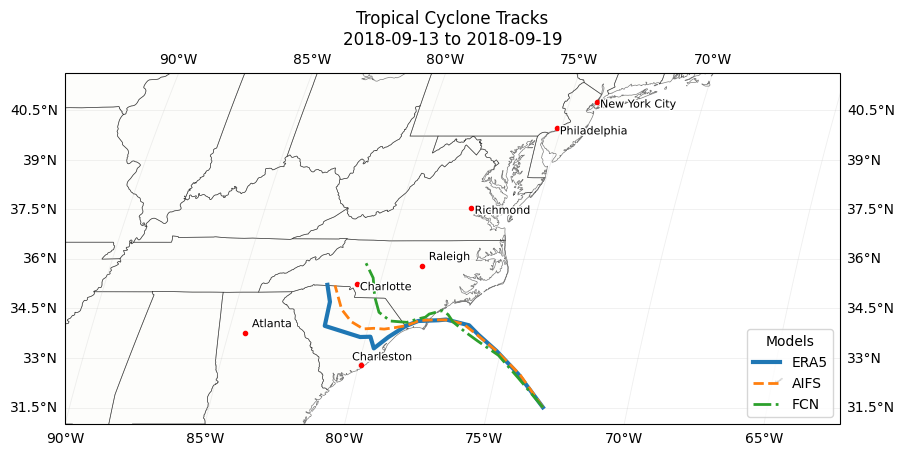

In [27]:
# Load saved tracks (or use variables from cells above)
era5_load = torch.load(FLORENCE_DIR / "era5_paths.pt", map_location="cpu")
aifs_load = torch.load(FLORENCE_DIR / "aifs_paths.pt", map_location="cpu")
fcn_load = torch.load(FLORENCE_DIR / "fcn_paths.pt", map_location="cpu")

cities = [
    ("Charlotte",    35.2271, -80.8431,  0.18, -0.18),
    ("Raleigh",      35.7796, -78.6382,  0.18,  0.18),
    ("Charleston",   32.7765, -79.9311, -0.35,  0.15),
    ("Atlanta",      33.7490, -84.3880,  0.18,  0.18),
    ("Richmond",     37.5407, -77.4360,  0.18, -0.18),
    ("Philadelphia", 39.9526, -75.1652,  0.18, -0.18),
    ("New York City", 40.7685, -73.9822,  0.18, -0.18),
]

models = [
    {"name": "ERA5",  "tracks": era5_load, "color": "#1f77b4", "lw": 3.0, "ls": "-"},
    {"name": "AIFS",  "tracks": aifs_load, "color": "#ff7f0e", "lw": 2.0, "ls": "--"},
    {"name": "FCN",   "tracks": fcn_load,  "color": "#2ca02c", "lw": 2.0, "ls": "-."},
]

plot_hurricane_tracks(
    models,
    start_time=START_TIME, end_time=END_TIME,
    extent=(-90, -65, 31, 41),
    cities=cities,
)


---
## 14-Day Extended Range Forecast: Aurora

Aurora (Microsoft, 2024) runs at 0.25° resolution with 6-hour timesteps.
Here we step it 56 times (14 days) from **January 5, 2025** — the onset of a
major polar vortex disruption — and animate the daily 500 hPa geopotential
height evolution over the Northern Hemisphere.


In [21]:
AURORA_START = "2025-01-05T00:00:00"
AURORA_STEPS = 56       # 14 days × 4 steps/day at 6h
AURORA_SAVE_EVERY = 4   # one frame per day
G = 9.80665             # m s⁻²

aurora_model = Aurora.load_model(Aurora.load_default_package())
aurora_model = aurora_model.to(DEVICE).eval()

gfs_source = GFS()
time_array = to_time_array([AURORA_START])
x, coords = fetch_data(
    source=gfs_source,
    time=time_array,
    variable=aurora_model.input_coords()["variable"],
    lead_time=aurora_model.input_coords()["lead_time"],
    device=DEVICE,
)
x, coords = map_coords(x, coords, aurora_model.input_coords())

z500_frames, frame_labels = [], []

iterator = aurora_model.create_iterator(x, coords)
for step, (x, coords) in tqdm(enumerate(iterator), total=AURORA_STEPS, desc="Aurora 14-day forecast"):
    if (step + 1) % AURORA_SAVE_EVERY == 0:
        var_list = list(coords["variable"])
        z_idx = var_list.index("z500")
        z500_frames.append(x[0, 0, z_idx].cpu().numpy())
        day = (step + 1) // AURORA_SAVE_EVERY
        valid = np.datetime64(AURORA_START) + np.timedelta64(day, "D")
        frame_labels.append(f"Day +{day}  ({str(valid)[:10]})") 
    if step + 1 >= AURORA_STEPS:
        break

print(f"Collected {len(z500_frames)} daily frames.")

del aurora_model
torch.cuda.empty_cache()

Fetching GFS data:   0%|          | 0/69 [00:00<?, ?it/s]

2026-06-01 21:09:52.508 | DEBUG    | earth2studio.data.gfs:fetch_array:367 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20250104/18/atmos/gfs.t18z.pgrb2.0p25.f000 337432030-1236730
2026-06-01 21:09:52.554 | DEBUG    | earth2studio.data.gfs:fetch_array:367 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20250104/18/atmos/gfs.t18z.pgrb2.0p25.f000 150792622-1046345
2026-06-01 21:09:52.586 | DEBUG    | earth2studio.data.gfs:fetch_array:367 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20250104/18/atmos/gfs.t18z.pgrb2.0p25.f000 262490294-964275
2026-06-01 21:09:52.623 | DEBUG    | earth2studio.data.gfs:fetch_array:367 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20250104/18/atmos/gfs.t18z.pgrb2.0p25.f000 191886636-752406
2026-06-01 21:09:52.653 | DEBUG    | earth2studio.data.gfs:fetch_array:367 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20250104/18/atmos/gfs.t18z.pgrb2.0p25.f000 341976915-937518

Fetching GFS data:   0%|          | 0/69 [00:00<?, ?it/s]

2026-06-01 21:09:52.711 | DEBUG    | earth2studio.data.gfs:fetch_array:367 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20250104/18/atmos/gfs.t18z.pgrb2.0p25.f000 154901605-812717
2026-06-01 21:09:52.753 | DEBUG    | earth2studio.data.gfs:fetch_array:367 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20250104/18/atmos/gfs.t18z.pgrb2.0p25.f000 358153916-936705
2026-06-01 21:09:52.806 | DEBUG    | earth2studio.data.gfs:fetch_array:367 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20250104/18/atmos/gfs.t18z.pgrb2.0p25.f000 234488513-822267
2026-06-01 21:09:52.846 | DEBUG    | earth2studio.data.gfs:fetch_array:367 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20250104/18/atmos/gfs.t18z.pgrb2.0p25.f000 302953413-1258846
2026-06-01 21:09:52.903 | DEBUG    | earth2studio.data.gfs:fetch_array:367 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20250104/18/atmos/gfs.t18z.pgrb2.0p25.f000 392953234-857321

Fetching GFS data:   0%|          | 0/69 [00:00<?, ?it/s]

...

2026-06-01 21:10:01.169 | DEBUG    | earth2studio.data.gfs:fetch_array:367 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20250105/00/atmos/gfs.t00z.pgrb2.0p25.f000 360200801-1237203

Fetching GFS data:   0%|          | 0/69 [00:04<?, ?it/s]

2026-06-01 21:10:01.373 | DEBUG    | earth2studio.data.gfs:fetch_array:367 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20250105/00/atmos/gfs.t00z.pgrb2.0p25.f000 172149831-1139103
2026-06-01 21:10:01.401 | DEBUG    | earth2studio.data.gfs:fetch_array:367 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20250105/00/atmos/gfs.t00z.pgrb2.0p25.f000 283811997-906969
2026-06-01 21:10:01.435 | DEBUG    | earth2studio.data.gfs:fetch_array:367 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20250105/00/atmos/gfs.t00z.pgrb2.0p25.f000 364691005-948120
2026-06-01 21:10:01.564 | DEBUG    | earth2studio.data.gfs:fetch_array:367 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20250105/00/atmos/gfs.t00z.pgrb2.0p25.f000 176598715-897206

Aurora 14-day forecast:  98%|█████████▊| 55/56 [05:13<00:05,  5.69s/it]

Collected 14 daily frames.

In [23]:
AURORA_START = "2025-01-05T00:00:00"
AURORA_STEPS = 56       # 14 days × 4 steps/day at 6h
AURORA_SAVE_EVERY = 4   # one frame per day
G = 9.80665             # m s⁻²

aurora_model = Aurora.load_model(Aurora.load_default_package())
aurora_model = aurora_model.to(DEVICE).eval()

gfs_source = GFS()
time_array = to_time_array([AURORA_START])
x, coords = fetch_data(
    source=gfs_source,
    time=time_array,
    variable=aurora_model.input_coords()["variable"],
    lead_time=aurora_model.input_coords()["lead_time"],
    device=DEVICE,
)
x, coords = map_coords(x, coords, aurora_model.input_coords())

z500_frames, frame_labels = [], []

iterator = aurora_model.create_iterator(x, coords)
for step, (x, coords) in tqdm(enumerate(iterator), total=AURORA_STEPS, desc="Aurora 14-day forecast"):
    if (step + 1) % AURORA_SAVE_EVERY == 0:
        var_list = list(coords["variable"])
        z_idx = var_list.index("z500")
        z500_frames.append(x[0, 0, z_idx].cpu().numpy())
        day = (step + 1) // AURORA_SAVE_EVERY
        valid = np.datetime64(AURORA_START) + np.timedelta64(day, "D")
        frame_labels.append(f"Day +{day}  ({str(valid)[:10]})") 
    if step + 1 >= AURORA_STEPS:
        break

print(f"Collected {len(z500_frames)} daily frames.")

del aurora_model
torch.cuda.empty_cache()

Fetching GFS data:   0%|          | 0/69 [00:00<?, ?it/s]

2026-06-01 21:16:54.574 | DEBUG    | earth2studio.data.gfs:fetch_array:367 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20250104/18/atmos/gfs.t18z.pgrb2.0p25.f000 259009093-1273217
2026-06-01 21:16:54.592 | DEBUG    | earth2studio.data.gfs:fetch_array:367 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20250104/18/atmos/gfs.t18z.pgrb2.0p25.f000 335224602-837932
2026-06-01 21:16:54.608 | DEBUG    | earth2studio.data.gfs:fetch_array:367 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20250104/18/atmos/gfs.t18z.pgrb2.0p25.f000 207941561-586515
2026-06-01 21:16:54.624 | DEBUG    | earth2studio.data.gfs:fetch_array:367 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20250104/18/atmos/gfs.t18z.pgrb2.0p25.f000 149771342-730280
2026-06-01 21:16:54.640 | DEBUG    | earth2studio.data.gfs:fetch_array:367 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20250104/18/atmos/gfs.t18z.pgrb2.0p25.f000 263454569-931682
2026-06-01 21:16:54.657 | DEBUG    | earth2studio.data.gfs:fetch_array:367 - Fetching GFS

Fetching GFS data:   0%|          | 0/69 [00:00<?, ?it/s]

2026-06-01 21:16:54.786 | DEBUG    | earth2studio.data.gfs:fetch_array:367 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20250104/18/atmos/gfs.t18z.pgrb2.0p25.f000 334328016-896586
2026-06-01 21:16:54.803 | DEBUG    | earth2studio.data.gfs:fetch_array:367 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20250104/18/atmos/gfs.t18z.pgrb2.0p25.f000 180719542-738762
2026-06-01 21:16:54.819 | DEBUG    | earth2studio.data.gfs:fetch_array:367 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20250104/18/atmos/gfs.t18z.pgrb2.0p25.f000 215424627-1178780
2026-06-01 21:16:54.836 | DEBUG    | earth2studio.data.gfs:fetch_array:367 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20250104/18/atmos/gfs.t18z.pgrb2.0p25.f000 278923123-733263
2026-06-01 21:16:54.851 | DEBUG    | earth2studio.data.gfs:fetch_array:367 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20250104/18/atmos/gfs.t18z.pgrb2.0p25.f000 186271333-967917
2026-06-01 21:16:54.867 | DEBUG    | earth2studio.data.gfs:fetch_array:367 - Fetching GFS

Fetching GFS data:   0%|          | 0/69 [00:00<?, ?it/s]

...

2026-06-01 21:16:56.681 | DEBUG    | earth2studio.data.gfs:fetch_array:367 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20250105/00/atmos/gfs.t00z.pgrb2.0p25.f000 364691005-948120
2026-06-01 21:16:56.697 | DEBUG    | earth2studio.data.gfs:fetch_array:367 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20250105/00/atmos/gfs.t00z.pgrb2.0p25.f000 176598715-897206
2026-06-01 21:16:56.713 | DEBUG    | earth2studio.data.gfs:fetch_array:367 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20250105/00/atmos/gfs.t00z.pgrb2.0p25.f000 360200801-1237203
2026-06-01 21:16:56.729 | DEBUG    | earth2studio.data.gfs:fetch_array:367 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20250105/00/atmos/gfs.t00z.pgrb2.0p25.f000 333299075-892383
2026-06-01 21:16:56.746 | DEBUG    | earth2studio.data.gfs:fetch_array:367 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20250105/00/atmos/gfs.t00z.pgrb2.0p25.f000 172149831-1139103
2026-06-01 21:16:56.762 | DEBUG    | earth2studio.data.gfs:fetch_array:367 - Fetching GF

Fetching GFS data:   0%|          | 0/69 [00:01<?, ?it/s]

2026-06-01 21:16:56.808 | DEBUG    | earth2studio.data.gfs:fetch_array:367 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20250105/00/atmos/gfs.t00z.pgrb2.0p25.f000 154749134-815119
2026-06-01 21:16:56.824 | DEBUG    | earth2studio.data.gfs:fetch_array:367 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20250105/00/atmos/gfs.t00z.pgrb2.0p25.f000 234508477-821871
2026-06-01 21:16:56.840 | DEBUG    | earth2studio.data.gfs:fetch_array:367 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20250105/00/atmos/gfs.t00z.pgrb2.0p25.f000 336373877-1230177
2026-06-01 21:16:56.856 | DEBUG    | earth2studio.data.gfs:fetch_array:367 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20250105/00/atmos/gfs.t00z.pgrb2.0p25.f000 150638435-1044453
2026-06-01 21:16:56.872 | DEBUG    | earth2studio.data.gfs:fetch_array:367 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20250105/00/atmos/gfs.t00z.pgrb2.0p25.f000 191795393-754367

Aurora 14-day forecast:  98%|█████████▊| 55/56 [05:15<00:05,  5.73s/it]

Collected 14 daily frames.

Saved: /home/jovyan/Earth2/aurora_outputs/aurora_z500_nh_14day.gif

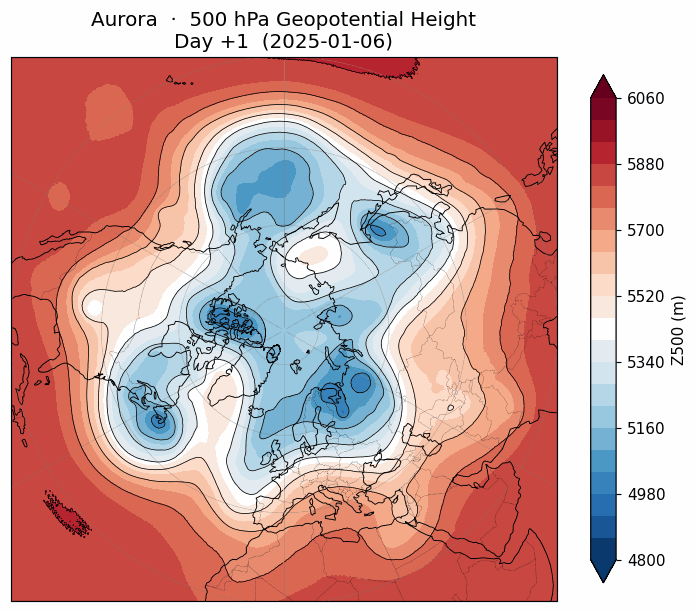

In [22]:
lats = np.asarray(coords["lat"])
lons = np.asarray(coords["lon"])

proj = ccrs.NorthPolarStereo()
frames_png = []

for z500, label in zip(z500_frames, frame_labels):
    z_height = z500 / G  # geopotential (m²/s²) → geopotential height (m)

    fig, ax = plt.subplots(1, 1, figsize=(8, 8), subplot_kw={"projection": proj})
    ax.set_extent([-180, 180, 20, 90], ccrs.PlateCarree())
    ax.add_feature(cfeature.COASTLINE, linewidth=0.6)
    ax.add_feature(cfeature.BORDERS, linewidth=0.3, linestyle=":")
    ax.gridlines(draw_labels=False, linewidth=0.4, color="gray", alpha=0.5)

    levels = np.arange(4800, 6100, 60)
    cf = ax.contourf(
        lons, lats, z_height, levels=levels,
        cmap="RdBu_r", transform=ccrs.PlateCarree(), extend="both",
    )
    ax.contour(
        lons, lats, z_height, levels=np.arange(4800, 6100, 120),
        colors="black", linewidths=0.5, transform=ccrs.PlateCarree(),
    )

    plt.colorbar(cf, ax=ax, label="Z500 (m)", shrink=0.75, pad=0.05)
    ax.set_title(f"Aurora  ·  500 hPa Geopotential Height\n{label}", fontsize=13)

    buf = io.BytesIO()
    fig.savefig(buf, format="png", dpi=110, bbox_inches="tight")
    buf.seek(0)
    frames_png.append(imageio.v2.imread(buf))
    plt.close(fig)

gif_path = PROJECT_DIR / "aurora_outputs/aurora_z500_nh_14day.gif"
imageio.mimsave(str(gif_path), frames_png, fps=2, loop=0)
print(f"Saved: {gif_path}")
IPImage(str(gif_path))